# Explainable AI Framework for Identity Fraud Detection at Bank Account Opening

## Notebook 3 - Statistical Testing, Explainability, Fairness and Robustness

**Sydney Ndabai (P2929107)** · CSIP5402 · Supervisor: Ahmad Lawal · De Montfort University

This notebook continues from the final model-development and evaluation workflow in Notebook 2.

The deployed model is the **XGBoost–LightGBM–Logistic Regression stacking ensemble with a Logistic Regression meta-learner**. No further hyperparameter selection is performed in this notebook.

The analyses address four remaining components of the framework:

1. statistical uncertainty and paired model comparison;
2. explanation of the deployed stacking ensemble using SHAP;
3. validation of explanation fidelity, agreement and stability, together with subgroup fairness analysis; and
4. external robustness evaluation using BAF Variant IV.

The frozen decision thresholds, fitted models and prediction scores produced in Notebook 2 are reused without modification.

## 0. Setup

Libraries are imported and the global random seed is fixed for reproducibility. The same seed used in Notebook 2 is retained.

In [1]:
import numpy as np
import pandas as pd
import random
import os
import time
import warnings
import joblib

import matplotlib.pyplot as plt

import sklearn
import xgboost
import lightgbm
import shap
import scipy

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from scipy.stats import spearmanr


SEED = 42

random.seed(SEED)
np.random.seed(SEED)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

for lib in [np, pd, sklearn, xgboost, lightgbm, shap, scipy]:
    print(f"{lib.__name__:14s} {lib.__version__}")

print(f"{'SEED':14s} {SEED}")

numpy          2.0.2
pandas         2.3.3
sklearn        1.6.1
xgboost        3.2.0
lightgbm       4.6.0
shap           0.51.0
scipy          1.16.3
SEED           42


### 0.1 Load Data and Final Notebook 2 Artefacts

The temporal partitions produced in Notebook 1 are reloaded together with the fitted models, frozen validation thresholds, probability scores and selected hyperparameters produced by the Notebook 2.

Notebook 3 performs no additional model selection. The stacking ensemble selected in Notebook 2 remains the deployed model throughout the statistical, explainability, fairness and robustness analyses.

In [2]:
NB1 = "/kaggle/input/notebooks/sydneyndabai/fyp-one"
NB2 = "/kaggle/input/notebooks/sydneyndabai/fypp-two"


# ------------------------------------------------------------
# Notebook 1: temporal data partitions
# ------------------------------------------------------------

train = pd.read_parquet(f"{NB1}/train.parquet")
val   = pd.read_parquet(f"{NB1}/val.parquet")
test  = pd.read_parquet(f"{NB1}/test.parquet")

cfg = joblib.load(f"{NB1}/feature_config.pkl")

TARGET = cfg["TARGET"]
feature_cols = cfg["feature_cols"]
categorical_cols = cfg["categorical_cols"]
numeric_cols = cfg["numeric_cols"]

X_train = train[feature_cols]
y_train = train[TARGET]

X_val = val[feature_cols]
y_val = val[TARGET]

X_test = test[feature_cols]
y_test = test[TARGET]

y_arr = y_test.to_numpy()


# ------------------------------------------------------------
# Notebook 2: frozen outputs
# ------------------------------------------------------------

thresholds = joblib.load(f"{NB2}/frozen_thresholds.pkl")
test_scores = joblib.load(f"{NB2}/test_scores.pkl")
val_scores = joblib.load(f"{NB2}/val_scores.pkl")
best_params = joblib.load(f"{NB2}/best_params.pkl")

results_nb2 = pd.read_csv(
    f"{NB2}/results_all_models.csv"
)


# ------------------------------------------------------------
# Fitted models
# ------------------------------------------------------------

stack_model = joblib.load(
    f"{NB2}/model_stacking_ensemble.pkl"
)

stack_rf_model = joblib.load(
    f"{NB2}/model_stack_+_random_forest.pkl"
)

lgbm_model = joblib.load(
    f"{NB2}/model_lightgbm.pkl"
)

xgb_model = joblib.load(
    f"{NB2}/model_xgboost.pkl"
)

lr_model = joblib.load(
    f"{NB2}/model_logistic_regression.pkl"
)

rf_model = joblib.load(
    f"{NB2}/model_random_forest.pkl"
)


# ------------------------------------------------------------
# Declare deployed model
# ------------------------------------------------------------

DEPLOYED_MODEL = "Stacking Ensemble"

deployed_model = stack_model
deployed_threshold = thresholds[DEPLOYED_MODEL]
deployed_scores = test_scores[DEPLOYED_MODEL]


# ------------------------------------------------------------
# Integrity checks
# ------------------------------------------------------------

EXPECTED_MODELS = {
    "Logistic Regression",
    "Random Forest",
    "XGBoost",
    "LightGBM",
    "Stacking Ensemble",
    "Stack + Random Forest"
}

loaded_models = set(test_scores.keys())

missing_models = EXPECTED_MODELS - loaded_models
unexpected_models = loaded_models - EXPECTED_MODELS

assert not missing_models, (
    f"Missing final Notebook 2 models: {missing_models}"
)

assert "Stack + LogReg" not in loaded_models, (
    "OLD NOTEBOOK 2 OUTPUT DETECTED: 'Stack + LogReg' is still present."
)

assert len(deployed_scores) == len(X_test), (
    "Stacking prediction length does not match test-set length."
)


print(f"Train set : {X_train.shape} | fraud rate = {y_train.mean():.4f}")
print(f"Val set   : {X_val.shape}   | fraud rate = {y_val.mean():.4f}")
print(f"Test set  : {X_test.shape}  | fraud rate = {y_test.mean():.4f}")

print(f"\nTest fraud cases: {int(y_test.sum()):,}")

print(f"\nDeployed model: {DEPLOYED_MODEL}")
print(f"Frozen threshold: {deployed_threshold:.4f}")

print("\nLoaded Notebook 2 models:")
for name in test_scores:
    print(f"  - {name}")

if unexpected_models:
    print(f"\nUnexpected saved models: {unexpected_models}")

print("\nNotebook 2 point estimates:")
display(
    results_nb2[
        ["Model", "TPR@5%FPR", "PR-AUC", "ROC-AUC"]
    ]
)

Train set : (794989, 35) | fraud rate = 0.0103
Val set   : (108168, 35)   | fraud rate = 0.0134
Test set  : (96843, 35)  | fraud rate = 0.0147

Test fraud cases: 1,428

Deployed model: Stacking Ensemble
Frozen threshold: 0.8651

Loaded Notebook 2 models:
  - Logistic Regression
  - Random Forest
  - XGBoost
  - LightGBM
  - Stacking Ensemble
  - Stack + Random Forest

Notebook 2 point estimates:


,Model,TPR@5%FPR,PR-AUC,ROC-AUC
0,Stacking Ensemble,0.5770,0.2161,0.8970
1,Stack + Random Forest,0.5763,0.2152,0.8969
2,LightGBM,0.5728,0.2172,0.8967
3,XGBoost,0.5616,0.2093,0.8929
4,Logistic Regression,0.5336,0.1849,0.8869
5,Random Forest,0.5182,0.1689,0.8771
6,Dummy (majority class),0.0500,0.0147,0.5000


In [3]:
def tpr_at_fpr(y_true, scores, target_fpr=0.05):
    """
    Interpolated true-positive rate at a specified false-positive rate.
    """
    fpr, tpr, _ = roc_curve(y_true, scores)

    return float(
        np.interp(target_fpr, fpr, tpr)
    )

## 1. Bootstrap Confidence Intervals

Notebook 2 provides point estimates of model performance, but small differences between models may reflect sampling variation in the held-out test month.

Stratified bootstrap resampling is therefore used to estimate 95% confidence intervals for TPR at 5% FPR, PR-AUC and ROC-AUC. Fraudulent and legitimate applications are resampled separately so that each bootstrap sample retains the observed test-set class counts.

These intervals quantify uncertainty in each model's own performance. They are not used to determine whether two models differ significantly; paired differences are assessed separately in Section 2 because all models are evaluated on the same applications.

In [4]:
def tpr_at_fpr(y_true, scores, target_fpr=0.05):
    """
    Interpolated true-positive rate at a specified false-positive rate.
    """
    fpr, tpr, _ = roc_curve(y_true, scores)

    return float(
        np.interp(target_fpr, fpr, tpr)
    )


MODEL_NAMES = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost",
    "LightGBM",
    "Stacking Ensemble",
    "Stack + Random Forest"
]


# ------------------------------------------------------------
# Point estimates
# ------------------------------------------------------------

point_metrics = {}

for name in MODEL_NAMES:

    s = np.asarray(test_scores[name])

    point_metrics[name] = {
        "TPR@5%FPR": tpr_at_fpr(
            y_arr,
            s,
            target_fpr=0.05
        ),

        "PR-AUC": average_precision_score(
            y_arr,
            s
        ),

        "ROC-AUC": roc_auc_score(
            y_arr,
            s
        )
    }


# ------------------------------------------------------------
# Stratified bootstrap
# ------------------------------------------------------------

B = 1000

pos_idx = np.where(y_arr == 1)[0]
neg_idx = np.where(y_arr == 0)[0]


boot_metrics = {
    name: {
        "TPR@5%FPR": np.empty(B),
        "PR-AUC": np.empty(B),
        "ROC-AUC": np.empty(B)
    }
    for name in MODEL_NAMES
}


# Fixed seeds mean the same bootstrap samples can be reused
# later for paired model comparisons.
seed_generator = np.random.RandomState(SEED)

bootstrap_seeds = seed_generator.randint(
    0,
    2**31 - 1,
    size=B
)


t0 = time.time()

for b, bootstrap_seed in enumerate(bootstrap_seeds):

    rng = np.random.RandomState(bootstrap_seed)

    sampled_pos = rng.choice(
        pos_idx,
        size=len(pos_idx),
        replace=True
    )

    sampled_neg = rng.choice(
        neg_idx,
        size=len(neg_idx),
        replace=True
    )

    idx = np.concatenate([
        sampled_pos,
        sampled_neg
    ])

    y_b = y_arr[idx]

    for name in MODEL_NAMES:

        s_b = np.asarray(test_scores[name])[idx]

        boot_metrics[name]["TPR@5%FPR"][b] = (
            tpr_at_fpr(
                y_b,
                s_b,
                target_fpr=0.05
            )
        )

        boot_metrics[name]["PR-AUC"][b] = (
            average_precision_score(
                y_b,
                s_b
            )
        )

        boot_metrics[name]["ROC-AUC"][b] = (
            roc_auc_score(
                y_b,
                s_b
            )
        )

    if (b + 1) % 100 == 0:
        print(
            f"Completed {b + 1:,}/{B:,} bootstrap resamples"
        )


print(
    f"\nBootstrap completed in "
    f"{(time.time() - t0) / 60:.1f} minutes"
)

Completed 100/1,000 bootstrap resamples
Completed 200/1,000 bootstrap resamples
Completed 300/1,000 bootstrap resamples
Completed 400/1,000 bootstrap resamples
Completed 500/1,000 bootstrap resamples
Completed 600/1,000 bootstrap resamples
Completed 700/1,000 bootstrap resamples
Completed 800/1,000 bootstrap resamples
Completed 900/1,000 bootstrap resamples
Completed 1,000/1,000 bootstrap resamples

Bootstrap completed in 6.9 minutes


In [5]:
ci_rows = []

for name in MODEL_NAMES:

    row = {
        "Model": name
    }

    for metric in [
        "TPR@5%FPR",
        "PR-AUC",
        "ROC-AUC"
    ]:

        distribution = boot_metrics[name][metric]

        low, high = np.percentile(
            distribution,
            [2.5, 97.5]
        )

        row[f"{metric}_point"] = (
            point_metrics[name][metric]
        )

        row[f"{metric}_low"] = low
        row[f"{metric}_high"] = high

    ci_rows.append(row)


ci_results = pd.DataFrame(ci_rows)


# Nice display version
ci_display = pd.DataFrame({
    "Model":
        ci_results["Model"],

    "TPR@5%FPR":
        ci_results.apply(
            lambda r:
            f"{r['TPR@5%FPR_point']:.4f} "
            f"[{r['TPR@5%FPR_low']:.4f}, "
            f"{r['TPR@5%FPR_high']:.4f}]",
            axis=1
        ),

    "PR-AUC":
        ci_results.apply(
            lambda r:
            f"{r['PR-AUC_point']:.4f} "
            f"[{r['PR-AUC_low']:.4f}, "
            f"{r['PR-AUC_high']:.4f}]",
            axis=1
        ),

    "ROC-AUC":
        ci_results.apply(
            lambda r:
            f"{r['ROC-AUC_point']:.4f} "
            f"[{r['ROC-AUC_low']:.4f}, "
            f"{r['ROC-AUC_high']:.4f}]",
            axis=1
        )
})


print("95% STRATIFIED BOOTSTRAP CONFIDENCE INTERVALS\n")

display(ci_display)

95% STRATIFIED BOOTSTRAP CONFIDENCE INTERVALS



,Model,TPR@5%FPR,PR-AUC,ROC-AUC
0,Logistic Regression,"0.5336 [0.5056, 0.5623]","0.1849 [0.1684, 0.2044]","0.8869 [0.8777, 0.8956]"
1,Random Forest,"0.5182 [0.4909, 0.5462]","0.1689 [0.1518, 0.1886]","0.8771 [0.8671, 0.8861]"
2,XGBoost,"0.5616 [0.5343, 0.5868]","0.2093 [0.1904, 0.2310]","0.8929 [0.8846, 0.9008]"
3,LightGBM,"0.5728 [0.5455, 0.5994]","0.2172 [0.1968, 0.2390]","0.8967 [0.8877, 0.9049]"
4,Stacking Ensemble,"0.5770 [0.5476, 0.6009]","0.2161 [0.1965, 0.2378]","0.8970 [0.8882, 0.9052]"
5,Stack + Random Forest,"0.5763 [0.5483, 0.6008]","0.2152 [0.1958, 0.2366]","0.8969 [0.8882, 0.9052]"


### 1.1 Interpretation of Bootstrap Confidence Intervals

The deployed stacking ensemble achieved the highest point estimate for TPR at 5% FPR (0.5770), followed closely by the Random-Forest-augmented stack (0.5763) and LightGBM (0.5728). Their confidence intervals overlap substantially, demonstrating that the differences among the leading models are small relative to the sampling uncertainty present in the held-out test month.

LightGBM produced the highest PR-AUC point estimate (0.2172), marginally exceeding the deployed stacking ensemble (0.2161). The stacking ensemble nevertheless produced the highest ROC-AUC point estimate (0.8970), although differences among the strongest models remained small.

These marginal confidence intervals describe uncertainty in each model's own performance and are not themselves tests of pairwise differences. Formal conclusions regarding differences between models are therefore based on the paired bootstrap analysis in Section 2.

## 2. Paired Bootstrap Model Comparison

Paired bootstrap analysis is used to determine whether observed performance differences between models are distinguishable from sampling variation.

Each pair of models is evaluated on exactly the same bootstrap resamples. The difference in performance is calculated within each resample, preserving the dependence created by evaluating competing models on the same test applications.

Two metrics are tested:

- **TPR at 5% FPR**, the study's primary fixed-operating-point metric; and
- **PR-AUC**, a prevalence-sensitive measure of ranking performance under severe class imbalance.

A 95% paired-difference interval that excludes zero provides evidence that the models differ on the corresponding metric. An interval containing zero indicates that the observed difference is not statistically distinguishable from zero on the available test sample.

In [6]:
def paired_bootstrap_result(
    model_a,
    model_b,
    metric
):
    """
    Difference is defined as:
        performance(model_a) - performance(model_b)
    """

    observed_diff = (
        point_metrics[model_a][metric]
        -
        point_metrics[model_b][metric]
    )

    bootstrap_diffs = (
        boot_metrics[model_a][metric]
        -
        boot_metrics[model_b][metric]
    )

    low, high = np.percentile(
        bootstrap_diffs,
        [2.5, 97.5]
    )

    if low > 0:
        conclusion = f"{model_a} higher"

    elif high < 0:
        conclusion = f"{model_b} higher"

    else:
        conclusion = "Not statistically distinguishable"

    return {
        "Model A": model_a,
        "Model B": model_b,
        "Metric": metric,
        "Observed difference": observed_diff,
        "95% CI lower": low,
        "95% CI upper": high,
        "Significant": (
            "Yes"
            if (low > 0 or high < 0)
            else "No"
        ),
        "Interpretation": conclusion
    }

In [7]:
PAIRS = [
    # Does the deployed stack outperform its strongest
    # individual gradient-boosted competitors?
    ("Stacking Ensemble", "LightGBM"),
    ("Stacking Ensemble", "XGBoost"),

    # Does adding another base learner improve the primary stack?
    ("Stacking Ensemble", "Stack + Random Forest"),

    # Does gradient boosting outperform the interpretable baseline?
    ("LightGBM", "Logistic Regression"),
    ("XGBoost", "Logistic Regression")
]


paired_rows = []

for model_a, model_b in PAIRS:

    for metric in [
        "TPR@5%FPR",
        "PR-AUC"
    ]:

        paired_rows.append(
            paired_bootstrap_result(
                model_a,
                model_b,
                metric
            )
        )


paired_results = pd.DataFrame(
    paired_rows
)


display_df = paired_results.copy()

display_df["Observed difference"] = (
    display_df["Observed difference"]
    .map(lambda x: f"{x:+.4f}")
)

display_df["95% CI"] = (
    paired_results.apply(
        lambda r:
        f"[{r['95% CI lower']:+.4f}, "
        f"{r['95% CI upper']:+.4f}]",
        axis=1
    )
)

display_df = display_df[
    [
        "Model A",
        "Model B",
        "Metric",
        "Observed difference",
        "95% CI",
        "Significant",
        "Interpretation"
    ]
]


print("PAIRED BOOTSTRAP MODEL COMPARISONS\n")

display(display_df)

PAIRED BOOTSTRAP MODEL COMPARISONS



,Model A,Model B,Metric,Observed difference,95% CI,Significant,Interpretation
0,Stacking Ensemble,LightGBM,TPR@5%FPR,+0.0042,"[-0.0063, +0.0140]",No,Not statistically distinguishable
1,Stacking Ensemble,LightGBM,PR-AUC,-0.0011,"[-0.0063, +0.0037]",No,Not statistically distinguishable
2,Stacking Ensemble,XGBoost,TPR@5%FPR,+0.0154,"[+0.0049, +0.0259]",Yes,Stacking Ensemble higher
3,Stacking Ensemble,XGBoost,PR-AUC,+0.0068,"[+0.0014, +0.0124]",Yes,Stacking Ensemble higher
4,Stacking Ensemble,Stack + Random Forest,TPR@5%FPR,+0.0007,"[-0.0014, +0.0028]",No,Not statistically distinguishable
5,Stacking Ensemble,Stack + Random Forest,PR-AUC,+0.0009,"[+0.0002, +0.0017]",Yes,Stacking Ensemble higher
6,LightGBM,Logistic Regression,TPR@5%FPR,+0.0392,"[+0.0210, +0.0588]",Yes,LightGBM higher
7,LightGBM,Logistic Regression,PR-AUC,+0.0323,"[+0.0199, +0.0451]",Yes,LightGBM higher
8,XGBoost,Logistic Regression,TPR@5%FPR,+0.0280,"[+0.0091, +0.0462]",Yes,XGBoost higher
9,XGBoost,Logistic Regression,PR-AUC,+0.0244,"[+0.0124, +0.0370]",Yes,XGBoost higher


### 2.1 Interpretation of Paired Bootstrap Results

The paired bootstrap analysis provides a more rigorous assessment of the performance differences observed in Notebook 2 by quantifying the uncertainty around each pairwise comparison.

**Stacking Ensemble versus LightGBM.** The deployed stacking ensemble achieved the highest TPR@5%FPR point estimate, exceeding LightGBM by 0.0042. The corresponding 95% confidence interval for the paired difference ranged from -0.0063 to +0.0140. For PR-AUC, LightGBM was marginally higher by 0.0011, with the paired confidence interval spanning -0.0063 to +0.0037. These results indicate that the two models perform at a closely comparable level on the held-out test set, with no clear evidence of a practically large separation between them. Importantly, the stacking ensemble maintains the strongest observed performance at the study's primary operating point, TPR@5%FPR, while LightGBM remains highly competitive across the precision-recall profile.

**Stacking Ensemble versus XGBoost.** The stacking ensemble showed a clearer advantage over XGBoost. It improved TPR@5%FPR by 0.0154, with a 95% confidence interval of +0.0049 to +0.0259, and improved PR-AUC by 0.0068, with a 95% confidence interval of +0.0014 to +0.0124. Since both confidence intervals remain above zero, the bootstrap analysis provides statistical support that the stacking architecture improves performance over XGBoost on both evaluation measures.

**Primary stack versus Random-Forest-augmented stack.** Adding Random Forest to the ensemble did not materially improve TPR@5%FPR. The primary three-learner stack retained a small advantage of +0.0007, with a 95% confidence interval of -0.0014 to +0.0028. The primary stack also achieved a slightly higher PR-AUC, with a difference of +0.0009 and a 95% confidence interval of +0.0002 to +0.0017. These findings suggest that increasing ensemble size does not automatically translate into stronger predictive performance. Given the additional computational cost of the four-learner configuration, the three-learner architecture provides a more efficient balance between predictive performance and model complexity.

**Gradient boosting versus Logistic Regression.** Both gradient-boosting models produced clear improvements over the linear baseline. LightGBM improved TPR@5%FPR by 0.0392 and PR-AUC by 0.0323 relative to Logistic Regression, while XGBoost improved the corresponding metrics by 0.0280 and 0.0244. All four paired confidence intervals excluded zero, providing statistical evidence that nonlinear gradient-boosted models capture predictive structure that is not fully represented by the linear baseline.

Overall, the bootstrap analysis supports a progressive but non-uniform benefit from increasing model complexity. The transition from Logistic Regression to gradient boosting produces clear and statistically supported gains. The primary stacking ensemble provides an additional improvement over XGBoost and achieves the highest observed TPR@5%FPR among the evaluated models. Its performance is closely matched by LightGBM, indicating that the value of stacking is most evident at the study's selected low-false-positive operating point rather than through universal dominance across all metrics. Extending the ensemble further with Random Forest does not provide meaningful additional improvement, suggesting that the three-learner stack represents a more efficient ensemble design.

## 3. Diagnostic Analysis of the Deployed Stacking Ensemble

The statistical analysis establishes whether the deployed ensemble differs from competing models, but does not explain how the stacking architecture combines its constituent learners.

The deployed model contains XGBoost, LightGBM and Logistic Regression as base learners, whose probability predictions are combined by a Logistic Regression meta-learner.

Two architecture-level diagnostics are examined:

1. the fitted meta-learner coefficients, which describe how the base-model probability outputs contribute to the final meta-model; and
2. pairwise correlations between the fitted base learners' probability predictions, which provide evidence about similarity and predictive diversity within the ensemble.

These diagnostics explain how the ensemble combines its component models. Feature-level explanation of the final deployed predictions is subsequently performed using SHAP in Section 4.

In [8]:
# ============================================================
# DEPLOYED STACKING ENSEMBLE DIAGNOSTICS
# ============================================================

meta = stack_model

# 1. Meta-learner coefficients
base_names = [name for name, _ in meta.estimators]
coefs = meta.final_estimator_.coef_[0]

coef_table = pd.DataFrame({
    "Base learner": base_names,
    "Meta coefficient": coefs,
    "Absolute coefficient magnitude": np.abs(coefs)
})

coef_table["Share of absolute coefficient magnitude"] = (
    coef_table["Absolute coefficient magnitude"]
    / coef_table["Absolute coefficient magnitude"].sum()
)

print("META-LEARNER COEFFICIENTS\n")
display(coef_table)

print(
    f"Meta-learner intercept: "
    f"{meta.final_estimator_.intercept_[0]:+.4f}"
)


# 2. Predictions from the actual fitted base learners
base_predictions = pd.DataFrame({
    "XGBoost":
        meta.named_estimators_["xgb"].predict_proba(X_test)[:, 1],

    "LightGBM":
        meta.named_estimators_["lgbm"].predict_proba(X_test)[:, 1],

    "Logistic Regression":
        meta.named_estimators_["lr"].predict_proba(X_test)[:, 1]
})

base_correlation = base_predictions.corr()

print("\nPAIRWISE BASE-LEARNER PREDICTION CORRELATIONS\n")
display(base_correlation)


# 3. Verify Notebook 2 -> Notebook 3 handoff
recomputed_stack_scores = stack_model.predict_proba(X_test)[:, 1]
saved_stack_scores = np.asarray(test_scores["Stacking Ensemble"])

max_score_difference = np.max(
    np.abs(recomputed_stack_scores - saved_stack_scores)
)

print(
    "\nMaximum difference between saved and "
    "recomputed stacking probabilities:"
)
print(f"{max_score_difference:.12f}")

assert max_score_difference < 1e-10, (
    "Loaded stacking model does not match "
    "the saved Notebook 2 predictions."
)

print(
    "\nHandoff verified: the loaded deployed model "
    "matches the final Notebook 2 predictions."
)

META-LEARNER COEFFICIENTS



,Base learner,Meta coefficient,Absolute coefficient magnitude,Share of absolute coefficient magnitude
0,xgb,1.473214,1.473214,0.258522
1,lgbm,3.112672,3.112672,0.546217
2,lr,1.112709,1.112709,0.195260


Meta-learner intercept: -2.6798

PAIRWISE BASE-LEARNER PREDICTION CORRELATIONS



,XGBoost,LightGBM,Logistic Regression
XGBoost,1.000000,0.977134,0.911076
LightGBM,0.977134,1.000000,0.921793
Logistic Regression,0.911076,0.921793,1.000000



Maximum difference between saved and recomputed stacking probabilities:
0.000000000000

Handoff verified: the loaded deployed model matches the final Notebook 2 predictions.


### 3.1 Interpretation of Ensemble Diagnostics

All three base learners received positive coefficients from the Logistic Regression meta-learner, indicating that higher fraud probabilities from each constituent model are associated with higher final ensemble fraud risk when the remaining base predictions are held constant.

LightGBM received the largest meta-learner coefficient (3.1127), followed by XGBoost (1.4732) and Logistic Regression (1.1127). The relative absolute coefficient magnitudes therefore suggest that LightGBM has the strongest association with the final meta-model output. These coefficient magnitudes are interpreted descriptively rather than as literal percentage contributions to individual predictions.

The base learners nevertheless produced strongly correlated probability estimates. XGBoost and LightGBM exhibited the highest correlation (r = 0.9771), while correlations between XGBoost and Logistic Regression (r = 0.9111) and between LightGBM and Logistic Regression (r = 0.9218) were also high. This indicates limited predictive diversity within the ensemble, which provides a plausible explanation for the relatively small performance improvement of stacking over LightGBM observed in the paired bootstrap analysis.

The Logistic Regression base learner is somewhat less correlated with the two gradient-boosted models, suggesting that it contributes a modest degree of complementary information despite being the weakest of the three individual learners.

Finally, the maximum difference between the saved Notebook 2 stacking probabilities and probabilities recomputed from the loaded model was zero to twelve decimal places. This verifies that Notebook 3 is evaluating the exact deployed stacking model produced in Notebook 2.

## 4. SHAP Explainability of the Deployed Stacking Ensemble

The deployed model is a heterogeneous stacking ensemble containing XGBoost, LightGBM and Logistic Regression base learners whose predicted fraud probabilities are combined by a Logistic Regression meta-learner.

Because the final prediction is generated by the complete stacking architecture rather than by any individual constituent model, SHAP is applied to the deployed ensemble as a whole. A model-agnostic SHAP approach is therefore required so that the resulting feature attributions correspond to the final fraud probability generated by the deployed model.

The analysis examines both global feature importance and individual prediction explanations. Explanation reliability is subsequently evaluated through fidelity, agreement and stability testing in Section 5.

In [9]:
# ============================================================
# MODEL-AGNOSTIC SHAP FOR THE DEPLOYED STACK
# ============================================================

shap_feature_names = list(feature_cols)
feature_dtypes = X_train.dtypes.to_dict()


def deployed_predict_proba(data):
    """
    Return fraud probabilities from the complete deployed
    stacking ensemble.
    """
    if isinstance(data, pd.DataFrame):
        df = data.copy()
        df.columns = shap_feature_names
    else:
        df = pd.DataFrame(data, columns=shap_feature_names)

    for col in shap_feature_names:
        if col in categorical_cols:
            try:
                df[col] = df[col].astype(feature_dtypes[col])
            except (TypeError, ValueError):
                df[col] = df[col].astype(str)
        else:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return deployed_model.predict_proba(df)[:, 1]


# Reproducible samples
BACKGROUND_N = 25
GLOBAL_N = 200
NSAMPLES = 200

rng_shap = np.random.RandomState(SEED)

background_idx = rng_shap.choice(
    len(X_train),
    size=BACKGROUND_N,
    replace=False
)

global_idx = rng_shap.choice(
    len(X_test),
    size=GLOBAL_N,
    replace=False
)

X_background = X_train.iloc[background_idx].copy()
X_shap = X_test.iloc[global_idx].copy()


print(
    f"Computing Kernel SHAP for {GLOBAL_N} test applications "
    f"using {BACKGROUND_N} background observations..."
)

t0 = time.time()

stack_explainer = shap.KernelExplainer(
    deployed_predict_proba,
    X_background,
    link="identity"
)

stack_shap_values = stack_explainer.shap_values(
    X_shap,
    nsamples=NSAMPLES,
    l1_reg=0.0
)

stack_shap_values = np.asarray(stack_shap_values)

print(
    f"\nSHAP completed in "
    f"{(time.time() - t0) / 60:.1f} minutes"
)

print(f"Applications explained: {stack_shap_values.shape[0]:,}")
print(f"Features explained: {stack_shap_values.shape[1]}")
print(f"SHAP array shape: {stack_shap_values.shape}")

Computing Kernel SHAP for 200 test applications using 25 background observations...


  0%|          | 0/200 [00:00<?, ?it/s]


SHAP completed in 0.5 minutes
Applications explained: 200
Features explained: 35
SHAP array shape: (200, 35)


TOP 15 GLOBAL SHAP FEATURES



,Feature,Mean |SHAP|
0,device_os,0.084561
1,phone_home_valid,0.063716
2,keep_alive_session,0.047243
3,housing_status,0.044779
4,has_other_cards,0.039465
5,email_is_free,0.039226
6,name_email_similarity,0.039092
7,current_address_months_count,0.038556
8,income,0.036417
9,prev_address_months_count,0.031052


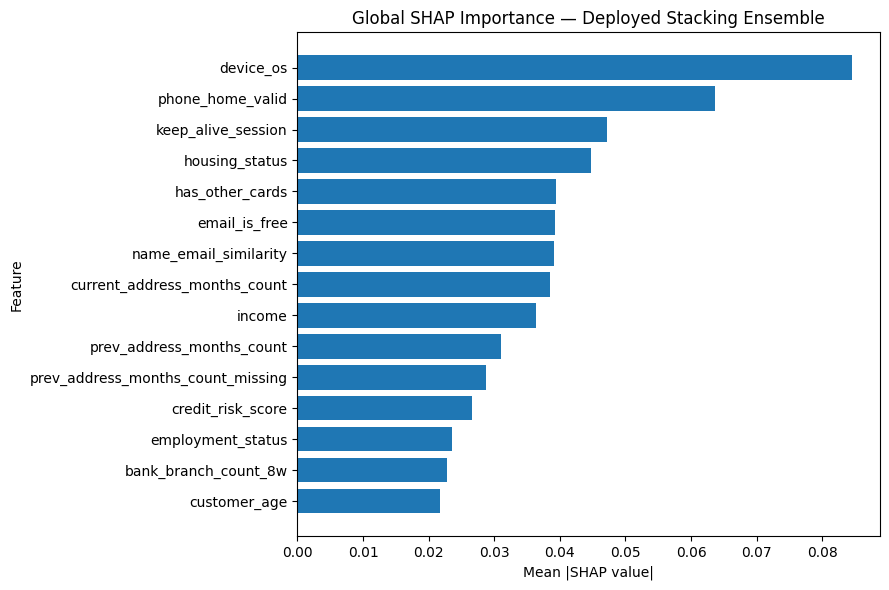

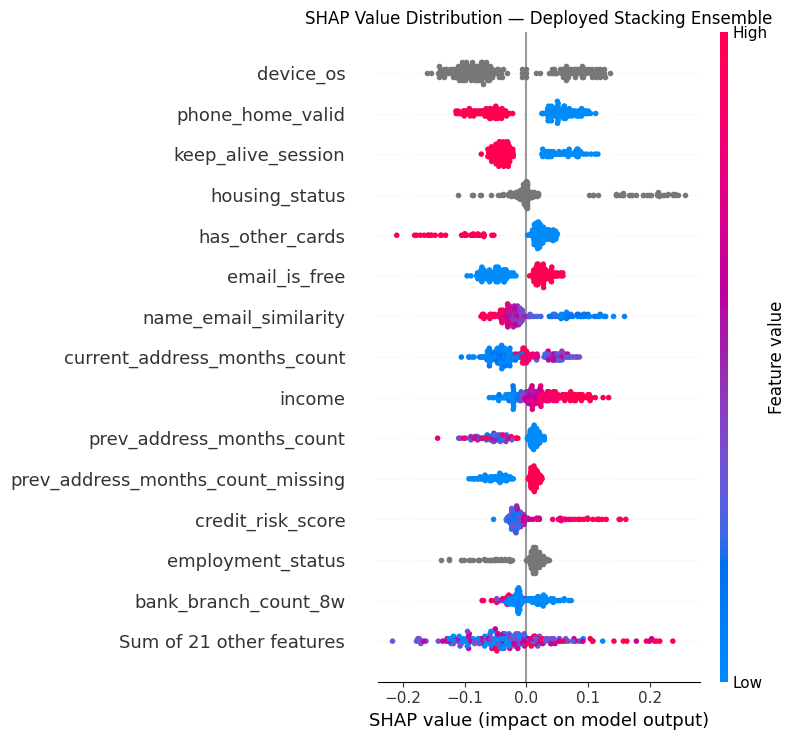

In [10]:
# ============================================================
# GLOBAL SHAP EXPLANATION OF THE DEPLOYED STACK
# ============================================================

# Mean absolute SHAP importance
mean_abs_shap = np.abs(stack_shap_values).mean(axis=0)

shap_importance = (
    pd.DataFrame({
        "Feature": shap_feature_names,
        "Mean |SHAP|": mean_abs_shap
    })
    .sort_values("Mean |SHAP|", ascending=False)
    .reset_index(drop=True)
)

print("TOP 15 GLOBAL SHAP FEATURES\n")
display(shap_importance.head(15))


# ------------------------------------------------------------
# 1. Global importance bar chart
# ------------------------------------------------------------

top15 = shap_importance.head(15)

plt.figure(figsize=(9, 6))

plt.barh(
    top15["Feature"][::-1],
    top15["Mean |SHAP|"][::-1]
)

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title(
    "Global SHAP Importance — Deployed Stacking Ensemble"
)

plt.tight_layout()
plt.savefig(
    "shap_global_importance_stack.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# ------------------------------------------------------------
# 2. SHAP beeswarm
# ------------------------------------------------------------

stack_explanation = shap.Explanation(
    values=stack_shap_values,
    base_values=np.repeat(
        float(np.asarray(stack_explainer.expected_value).squeeze()),
        len(X_shap)
    ),
    data=X_shap,
    feature_names=shap_feature_names
)

shap.plots.beeswarm(
    stack_explanation,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Value Distribution — Deployed Stacking Ensemble"
)

plt.tight_layout()
plt.savefig(
    "shap_beeswarm_stack.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

### 4.1 Global SHAP Findings

The global SHAP analysis shows that the deployed stacking ensemble relies on a mixture of device, contact, identity-consistency, address, financial and application-history characteristics.

`device_os` produced the largest mean absolute SHAP value (0.0846), followed by `phone_home_valid` (0.0637), `keep_alive_session` (0.0472) and `housing_status` (0.0448). Other influential variables included `has_other_cards`, `name_email_similarity`, `email_is_free`, address-duration measures, income and credit-risk score.

The presence of both `prev_address_months_count` and `prev_address_months_count_missing` among the highest-ranked features indicates that both the observed address-history value and whether that information is unavailable contribute to the ensemble's predictions.

The SHAP distribution also demonstrates that feature effects are not uniform across applications. Higher values of `phone_home_valid`, `keep_alive_session`, `has_other_cards` and `name_email_similarity` are generally associated with negative SHAP values, whereas lower values more frequently increase predicted fraud risk. Conversely, higher values of variables including `email_is_free`, `income`, `prev_address_months_count_missing` and `credit_risk_score` tend to be associated with positive SHAP contributions within the explanation sample.

These relationships describe how the fitted model behaves and should not be interpreted as causal effects. For categorical variables such as `device_os`, `housing_status` and `employment_status`, global importance can be interpreted from the magnitude of their SHAP values, but the numerical colour scale of the beeswarm does not provide a meaningful ordered high-versus-low interpretation.

Frozen stacking threshold: 0.8651

True Positive: actual=1, predicted probability=0.9241
False Positive: actual=0, predicted probability=0.9060
False Negative: actual=1, predicted probability=0.6002


  0%|          | 0/3 [00:00<?, ?it/s]

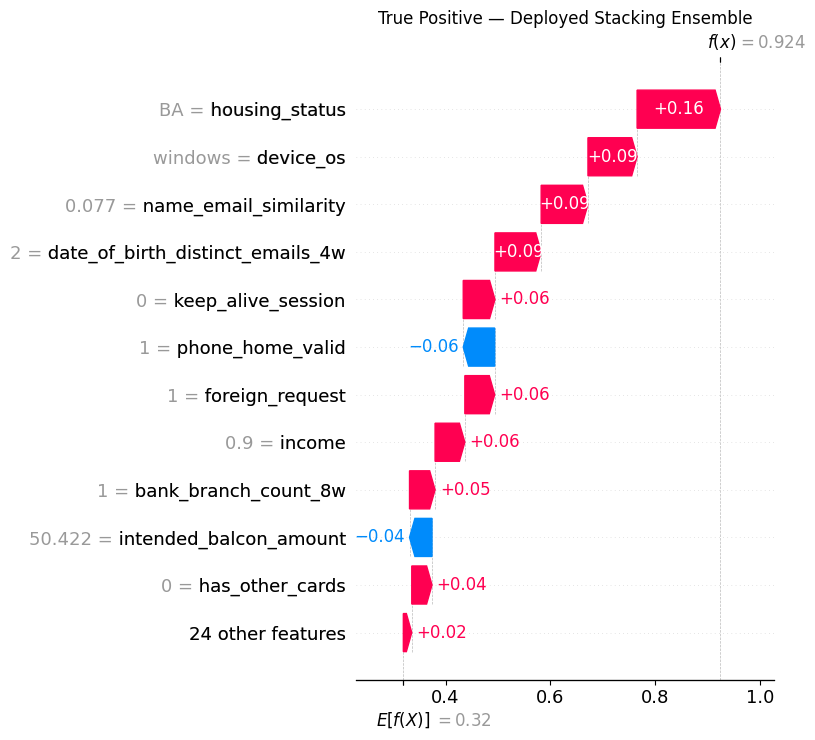

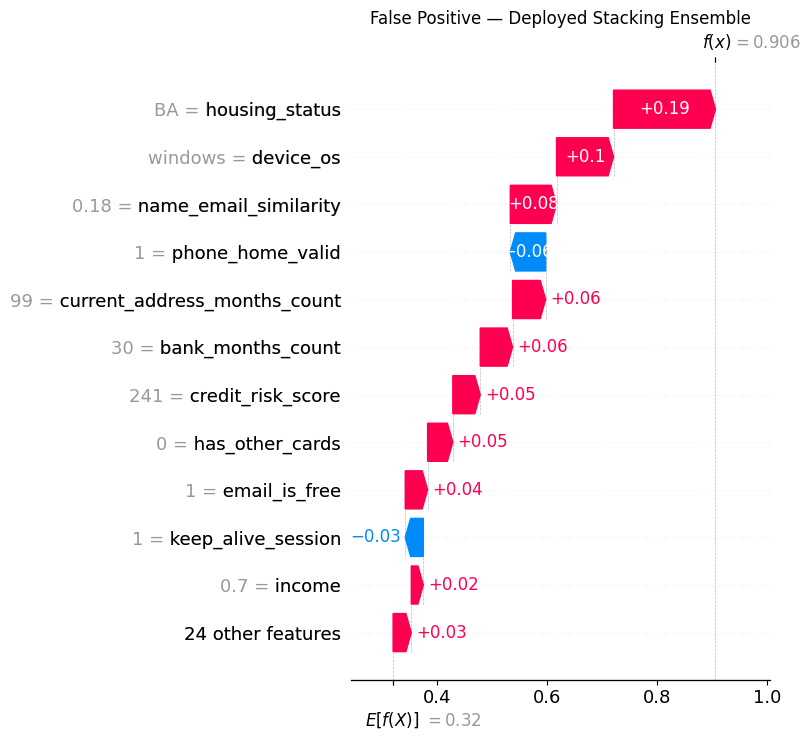

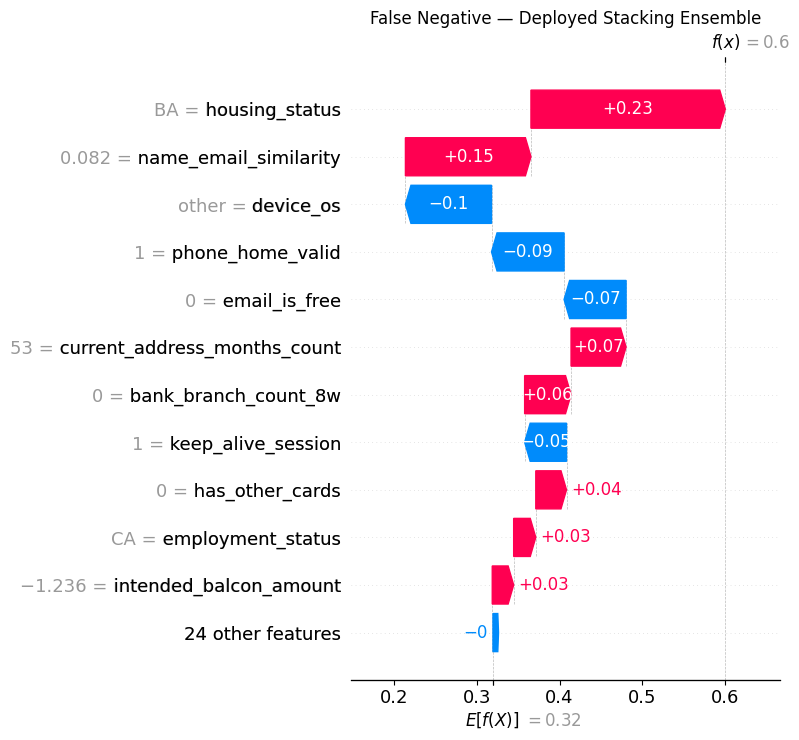

In [11]:
# ============================================================
# INDIVIDUAL SHAP EXPLANATIONS
# ============================================================

stack_scores = np.asarray(test_scores["Stacking Ensemble"])
stack_threshold = thresholds["Stacking Ensemble"]

stack_pred = (stack_scores >= stack_threshold).astype(int)

tp_idx = np.where((y_arr == 1) & (stack_pred == 1))[0]
fp_idx = np.where((y_arr == 0) & (stack_pred == 1))[0]
fn_idx = np.where((y_arr == 1) & (stack_pred == 0))[0]


def median_score_case(indices, scores):
    """Select a typical case based on the median score within the group."""
    ordered = indices[np.argsort(scores[indices])]
    return ordered[len(ordered) // 2]


case_indices = {
    "True Positive": median_score_case(tp_idx, stack_scores),
    "False Positive": median_score_case(fp_idx, stack_scores),
    "False Negative": median_score_case(fn_idx, stack_scores)
}


print(f"Frozen stacking threshold: {stack_threshold:.4f}\n")

for label, idx in case_indices.items():
    print(
        f"{label}: "
        f"actual={y_arr[idx]}, "
        f"predicted probability={stack_scores[idx]:.4f}"
    )


# Explain the three selected cases
case_rows = list(case_indices.values())
X_cases = X_test.iloc[case_rows].copy()

case_shap_values = stack_explainer.shap_values(
    X_cases,
    nsamples=500,
    l1_reg=0.0
)

case_shap_values = np.asarray(case_shap_values)

base_value = float(
    np.asarray(stack_explainer.expected_value).squeeze()
)

case_explanation = shap.Explanation(
    values=case_shap_values,
    base_values=np.repeat(base_value, len(X_cases)),
    data=X_cases.values,
    feature_names=shap_feature_names
)


for j, label in enumerate(case_indices.keys()):

    shap.plots.waterfall(
        case_explanation[j],
        max_display=12,
        show=False
    )

    plt.title(f"{label} — Deployed Stacking Ensemble")
    plt.tight_layout()

    filename = label.lower().replace(" ", "_")

    plt.savefig(
        f"shap_{filename}_stack.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

### 4.2 Individual Prediction Explanations

Three median-score applications were selected from the true-positive, false-positive and false-negative groups defined using the deployed stacking ensemble's frozen threshold of 0.8651. Selecting the median-scored case within each outcome group provides illustrative cases without deliberately choosing the most extreme predictions.

**True positive.** The correctly detected fraud case received a model score of 0.9241, above the frozen decision threshold. The strongest positive contributions included `housing_status`, `name_email_similarity`, `device_os` and `date_of_birth_distinct_emails_4w`. These effects were partially offset by features including `phone_home_valid`, `intended_balcon_amount` and `email_is_free`, but the combined evidence remained sufficient for the application to be classified as fraud.

**False positive.** The legitimate application received a score of 0.9060 and was therefore incorrectly flagged. Positive contributions from `housing_status`, `device_os`, `name_email_similarity`, `current_address_months_count`, `bank_months_count` and other features outweighed negative contributions from variables including `phone_home_valid` and `keep_alive_session`. This case illustrates how combinations of individually plausible characteristics can produce a high fraud score for a legitimate applicant, highlighting the importance of individual explanation where false positives may lead to unnecessary review or adverse decisions.

**False negative.** The undetected fraud case received a score of 0.6002, substantially below the frozen threshold. Although `housing_status`, `name_email_similarity`, `current_address_months_count` and `bank_branch_count_8w` increased the model score, these effects were counteracted by negative contributions from `device_os`, `phone_home_valid`, `email_is_free` and `keep_alive_session`. The resulting score remained below the operating threshold and the fraudulent application was missed.

Taken together, the examples demonstrate that the stacking ensemble's decisions arise from combinations of features rather than a single dominant characteristic. They also show that similar influential variables can contribute to both correct and incorrect classifications depending on their values and interaction with the remaining application information. SHAP values describe the fitted model's attribution of its output and should not be interpreted as causal effects.

The SHAP baseline shown in the waterfall plots, \(E[f(X)]\), represents the expected model output over the selected SHAP background sample rather than the observed fraud prevalence in the dataset.

## 5. Explanation Reliability

Producing SHAP explanations does not establish that those explanations are reliable. The proposal therefore evaluates the deployed model's explanations using three complementary tests.

- **Fidelity:** whether removing the features ranked most important by SHAP materially reduces the predictive performance of the same stacking architecture.
- **Agreement:** whether an independently fitted model identifies a similar ordering of important features.
- **Stability:** whether the principal SHAP feature rankings remain similar when the stacking architecture is trained under different random initialisations.

Together, these analyses assess whether the explanations reflect reproducible predictive structure rather than being treated as reliable solely because SHAP produced an attribution.

In [12]:
top5_features = shap_importance.head(5)["Feature"].tolist()

for i, feature in enumerate(top5_features, 1):
    print(f"{i}. {feature}")

1. device_os
2. phone_home_valid
3. keep_alive_session
4. housing_status
5. has_other_cards


### 5.1 Fidelity

Fidelity is assessed by removing the five features ranked most important by the deployed model's global SHAP analysis and retraining the same stacking architecture without further hyperparameter tuning. Performance is then compared with the original deployed stack on the held-out test month.

A substantial reduction in TPR at 5% FPR or PR-AUC would provide evidence that the features assigned the greatest SHAP importance also contain substantial predictive information.

In [13]:
# ============================================================
# SHAP FIDELITY: REMOVE TOP-5 FEATURES
# ============================================================

top5_features = shap_importance.head(5)["Feature"].tolist()

remaining_features = [
    col for col in feature_cols
    if col not in top5_features
]

print("Top 5 SHAP features removed:")
for i, feature in enumerate(top5_features, 1):
    print(f"{i}. {feature}")

print(
    f"\nFeatures retained: "
    f"{len(remaining_features)} / {len(feature_cols)}"
)


# ------------------------------------------------------------
# Rebuild each fitted base pipeline with the same settings,
# changing only the preprocessing feature lists.
# ------------------------------------------------------------

def make_reduced_pipeline(fitted_estimator, retained_features):
    """
    Clone a fitted base-learner pipeline and rebuild its preprocessing
    so that only retained_features are used.

    The original remainder behaviour is preserved:
    - tree models: remainder='passthrough'
    - linear model: remainder='drop'
    """

    # Clone the full estimator so the Notebook 2 hyperparameters are preserved
    reduced_estimator = clone(fitted_estimator)

    # Locate the preprocessing ColumnTransformer
    prep_step_name = None
    fitted_prep = None

    for step_name, step in fitted_estimator.steps:
        if isinstance(step, ColumnTransformer):
            prep_step_name = step_name
            fitted_prep = step
            break

    if fitted_prep is None:
        raise ValueError(
            "No ColumnTransformer found in fitted base learner."
        )

    # Rebuild explicitly defined transformers using only retained features
    new_transformers = []

    for name, transformer, columns in fitted_prep.transformers:

        retained_columns = [
            col for col in columns
            if col in retained_features
        ]

        if len(retained_columns) == 0:
            continue

        if transformer in ("drop", "passthrough"):
            new_transformer = transformer
        else:
            new_transformer = clone(transformer)

        new_transformers.append(
            (
                name,
                new_transformer,
                retained_columns
            )
        )

    # IMPORTANT:
    # Preserve the original remainder setting.
    # XGBoost/LightGBM use "passthrough" for numerical variables.
    # Logistic Regression uses "drop" because its numerical variables
    # are explicitly handled by StandardScaler.
    reduced_prep = ColumnTransformer(
        transformers=new_transformers,
        remainder=fitted_prep.remainder,
        verbose_feature_names_out=False
    )

    # Replace only the preprocessing stage
    reduced_estimator.set_params(
        **{prep_step_name: reduced_prep}
    )

    return reduced_estimator



xgb_reduced = make_reduced_pipeline(
    stack_model.named_estimators_["xgb"],
    remaining_features
)

lgbm_reduced = make_reduced_pipeline(
    stack_model.named_estimators_["lgbm"],
    remaining_features
)

lr_reduced = make_reduced_pipeline(
    stack_model.named_estimators_["lr"],
    remaining_features
)


# ------------------------------------------------------------
# Same three-learner stacking architecture
# ------------------------------------------------------------

fidelity_stack = StackingClassifier(
    estimators=[
        ("xgb", xgb_reduced),
        ("lgbm", lgbm_reduced),
        ("lr", lr_reduced)
    ],
    final_estimator=clone(
        stack_model.final_estimator_
    ),
    stack_method="predict_proba",
    cv=stack_model.cv,
    n_jobs=-1
)


# ------------------------------------------------------------
# Retrain once with the top-5 SHAP features removed.
# No hyperparameter retuning.
# ------------------------------------------------------------

t0 = time.time()

fidelity_stack.fit(
    X_train[remaining_features],
    y_train
)

print(
    f"\nReduced stack trained in "
    f"{(time.time() - t0) / 60:.1f} minutes"
)


fidelity_scores = fidelity_stack.predict_proba(
    X_test[remaining_features]
)[:, 1]


# ------------------------------------------------------------
# Compare predictive performance
# ------------------------------------------------------------

original_tpr = tpr_at_fpr(
    y_arr,
    deployed_scores,
    target_fpr=0.05
)

reduced_tpr = tpr_at_fpr(
    y_arr,
    fidelity_scores,
    target_fpr=0.05
)

original_pr = average_precision_score(
    y_arr,
    deployed_scores
)

reduced_pr = average_precision_score(
    y_arr,
    fidelity_scores
)


fidelity_results = pd.DataFrame({
    "Metric": [
        "TPR@5%FPR",
        "PR-AUC"
    ],

    "Original stack": [
        original_tpr,
        original_pr
    ],

    "Without top-5 SHAP features": [
        reduced_tpr,
        reduced_pr
    ]
})

fidelity_results["Performance drop"] = (
    fidelity_results["Original stack"]
    - fidelity_results["Without top-5 SHAP features"]
)


print("\nSHAP FIDELITY RESULTS\n")
display(fidelity_results)

Top 5 SHAP features removed:
1. device_os
2. phone_home_valid
3. keep_alive_session
4. housing_status
5. has_other_cards

Features retained: 30 / 35


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Reduced stack trained in 2.9 minutes

SHAP FIDELITY RESULTS



,Metric,Original stack,Without top-5 SHAP features,Performance drop
0,TPR@5%FPR,0.577031,0.431373,0.145658
1,PR-AUC,0.216144,0.144414,0.071731


### 5.2 Agreement Across Architectures

Agreement is assessed by comparing the global SHAP feature ranking of the deployed stacking ensemble with that of the independently fitted Random Forest model.

The same background observations, held-out explanation sample and model-agnostic SHAP procedure are used for both models so that differences in the resulting rankings primarily reflect differences between the predictive architectures rather than differences in explanation method or sampled observations.

Agreement is quantified using Spearman rank correlation across all features and overlap among the ten highest-ranked features.

In [14]:
# ============================================================
# SHAP AGREEMENT: DEPLOYED STACK vs RANDOM FOREST
# ============================================================

def rf_predict_proba(data):
    """Return fraud scores from the fitted Random Forest model."""

    if isinstance(data, pd.DataFrame):
        df = data.copy()
        df.columns = shap_feature_names
    else:
        df = pd.DataFrame(
            data,
            columns=shap_feature_names
        )

    for col in shap_feature_names:
        if col in categorical_cols:
            try:
                df[col] = df[col].astype(feature_dtypes[col])
            except (TypeError, ValueError):
                df[col] = df[col].astype(str)
        else:
            df[col] = pd.to_numeric(
                df[col],
                errors="coerce"
            )

    return rf_model.predict_proba(df)[:, 1]


# Same background and explanation sample used for the stack
rf_explainer = shap.KernelExplainer(
    rf_predict_proba,
    X_background,
    link="identity"
)

rf_shap_values = rf_explainer.shap_values(
    X_shap,
    nsamples=NSAMPLES,
    l1_reg=0.0
)

rf_shap_values = np.asarray(rf_shap_values)


# ------------------------------------------------------------
# Global Random Forest SHAP ranking
# ------------------------------------------------------------

rf_importance = (
    pd.DataFrame({
        "Feature": shap_feature_names,
        "Mean |SHAP|":
            np.abs(rf_shap_values).mean(axis=0)
    })
    .sort_values("Mean |SHAP|", ascending=False)
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Compare rankings
# ------------------------------------------------------------

stack_rank = (
    shap_importance
    .set_index("Feature")["Mean |SHAP|"]
    .rank(ascending=False)
)

rf_rank = (
    rf_importance
    .set_index("Feature")["Mean |SHAP|"]
    .rank(ascending=False)
)

rho, p_value = spearmanr(
    stack_rank.loc[shap_feature_names],
    rf_rank.loc[shap_feature_names]
)

stack_top10 = set(
    shap_importance.head(10)["Feature"]
)

rf_top10 = set(
    rf_importance.head(10)["Feature"]
)

shared_top10 = stack_top10 & rf_top10
top10_overlap = len(shared_top10)


print("SHAP AGREEMENT RESULTS\n")

print(f"Spearman rank correlation: {rho:.4f}")
print(f"Spearman p-value:          {p_value:.4g}")
print(f"Top-10 overlap:            {top10_overlap}/10")

print("\nShared top-10 features:")
for feature in sorted(shared_top10):
    print(f" - {feature}")

print("\nRandom Forest top 10:")
display(rf_importance.head(10))

  0%|          | 0/200 [00:00<?, ?it/s]

SHAP AGREEMENT RESULTS

Spearman rank correlation: 0.9633
Spearman p-value:          2.023e-20
Top-10 overlap:            9/10

Shared top-10 features:
 - current_address_months_count
 - device_os
 - email_is_free
 - has_other_cards
 - housing_status
 - keep_alive_session
 - name_email_similarity
 - phone_home_valid
 - prev_address_months_count

Random Forest top 10:


,Feature,Mean |SHAP|
0,device_os,0.057136
1,phone_home_valid,0.030881
2,housing_status,0.028411
3,current_address_months_count,0.028368
4,prev_address_months_count,0.024823
5,keep_alive_session,0.023087
6,prev_address_months_count_missing,0.021983
7,has_other_cards,0.020699
8,name_email_similarity,0.017647
9,email_is_free,0.014389


### 5.3 Stability Across Random Initialisations

In [15]:
# ============================================================
# SHAP STABILITY ACROSS RANDOM INITIALISATIONS
# ============================================================

STABILITY_SEEDS = [7, 21, 101]

# Seed 42 is the already-fitted deployed model
stability_importances = {
    42: shap_importance.set_index("Feature")["Mean |SHAP|"]
}

stability_rows = []


def set_all_random_states(estimator, seed):
    """
    Set every available random_state parameter in a cloned
    stacking architecture to the same seed.
    """
    params = estimator.get_params(deep=True)

    seed_params = {
        key: seed
        for key in params
        if key.endswith("random_state")
    }

    estimator.set_params(**seed_params)

    return estimator


for seed in STABILITY_SEEDS:

    print(f"\nTraining stack with random seed {seed}...")

    # Same architecture and hyperparameters, different initialisation
    seeded_stack = clone(stack_model)
    seeded_stack = set_all_random_states(
        seeded_stack,
        seed
    )

    seeded_stack.fit(
        X_train,
        y_train
    )


    def seeded_predict_proba(data):

        if isinstance(data, pd.DataFrame):
            df = data.copy()
            df.columns = shap_feature_names
        else:
            df = pd.DataFrame(
                data,
                columns=shap_feature_names
            )

        for col in shap_feature_names:
            if col in categorical_cols:
                try:
                    df[col] = df[col].astype(
                        feature_dtypes[col]
                    )
                except (TypeError, ValueError):
                    df[col] = df[col].astype(str)
            else:
                df[col] = pd.to_numeric(
                    df[col],
                    errors="coerce"
                )

        return seeded_stack.predict_proba(df)[:, 1]


    # Same SHAP background and same test observations
    seeded_explainer = shap.KernelExplainer(
        seeded_predict_proba,
        X_background,
        link="identity"
    )

    seeded_shap = seeded_explainer.shap_values(
        X_shap,
        nsamples=NSAMPLES,
        l1_reg=0.0
    )

    seeded_shap = np.asarray(seeded_shap)

    seeded_importance = pd.Series(
        np.abs(seeded_shap).mean(axis=0),
        index=shap_feature_names
    )

    stability_importances[seed] = seeded_importance


# ------------------------------------------------------------
# Compare each seed with the deployed model (seed 42)
# ------------------------------------------------------------

reference = stability_importances[42]

reference_rank = reference.rank(
    ascending=False
)

reference_top10 = set(
    reference
    .sort_values(ascending=False)
    .head(10)
    .index
)


for seed in STABILITY_SEEDS:

    comparison = stability_importances[seed]

    comparison_rank = comparison.rank(
        ascending=False
    )

    rho, p_value = spearmanr(
        reference_rank.loc[shap_feature_names],
        comparison_rank.loc[shap_feature_names]
    )

    comparison_top10 = set(
        comparison
        .sort_values(ascending=False)
        .head(10)
        .index
    )

    overlap = len(
        reference_top10 & comparison_top10
    )

    stability_rows.append({
        "Seed comparison": f"42 vs {seed}",
        "Spearman rho": rho,
        "p-value": p_value,
        "Top-10 overlap": overlap
    })


stability_results = pd.DataFrame(
    stability_rows
)

print("\nSHAP STABILITY RESULTS\n")
display(stability_results)


Training stack with random seed 7...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  0%|          | 0/200 [00:00<?, ?it/s]


Training stack with random seed 21...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...


Training stack with random seed 101...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  0%|          | 0/200 [00:00<?, ?it/s]


SHAP STABILITY RESULTS



,Seed comparison,Spearman rho,p-value,Top-10 overlap
0,42 vs 7,0.998599,1.039741e-43,10
1,42 vs 21,0.996918,4.587326e-38,10
2,42 vs 101,0.996918,4.587326e-38,10


## 6. Fairness and Predictive Equality Audit

Fairness is evaluated using predictive equality, consistent with the BAF benchmark. The deployed stacking ensemble is assessed at its previously frozen operating threshold so that subgroup analysis reflects the same decisions used in the primary evaluation.

Following Jesus et al. (2022), applicants are divided into two age groups: **customer age ≤ 50** and **customer age > 50**. For each group, sample size, fraud prevalence, false-positive rate and true-positive rate are reported. Predictive equality is summarised as the ratio between the lower and higher observed group false-positive rates, where values closer to one indicate more similar false-positive rates between groups.

In [16]:
# ============================================================
# FAIRNESS AUDIT — PREDICTIVE EQUALITY BY AGE
# ============================================================

fairness_scores = np.asarray(
    test_scores["Stacking Ensemble"]
)

fairness_threshold = thresholds[
    "Stacking Ensemble"
]

fairness_pred = (
    fairness_scores >= fairness_threshold
).astype(int)


# BAF benchmark age grouping
age_group = np.where(
    X_test["customer_age"].to_numpy() > 50,
    "Age > 50",
    "Age ≤ 50"
)


fairness_rows = []

for group in ["Age ≤ 50", "Age > 50"]:

    mask = age_group == group

    y_group = y_arr[mask]
    pred_group = fairness_pred[mask]

    tn, fp, fn, tp = confusion_matrix(
        y_group,
        pred_group,
        labels=[0, 1]
    ).ravel()

    fpr = fp / (fp + tn)
    tpr = tp / (tp + fn)

    fairness_rows.append({
        "Group": group,
        "N": len(y_group),
        "Fraud prevalence": y_group.mean(),
        "FPR": fpr,
        "TPR": tpr,
        "False positives": fp,
        "True negatives": tn,
        "False negatives": fn,
        "True positives": tp
    })


fairness_results = pd.DataFrame(
    fairness_rows
)


# ------------------------------------------------------------
# Predictive equality
# BAF definition: lower observed FPR / higher observed FPR
# ------------------------------------------------------------

group_fprs = fairness_results["FPR"].to_numpy()

predictive_equality_ratio = (
    group_fprs.min() / group_fprs.max()
)

fpr_gap = (
    group_fprs.max() - group_fprs.min()
)


print("PREDICTIVE EQUALITY — CUSTOMER AGE\n")

display(fairness_results)

print(
    f"Predictive equality ratio: "
    f"{predictive_equality_ratio:.4f}"
)

print(
    f"Absolute FPR gap: "
    f"{fpr_gap:.4f}"
)

PREDICTIVE EQUALITY — CUSTOMER AGE



,Group,N,Fraud prevalence,FPR,TPR,False positives,True negatives,False negatives,True positives
0,Age ≤ 50,93901,0.013482,0.036520,0.500000,3383,89252,633,633
1,Age > 50,2942,0.055065,0.126619,0.691358,352,2428,50,112


Predictive equality ratio: 0.2884
Absolute FPR gap: 0.0901


### 6.1 Interpretation of Fairness Results

The deployed stacking ensemble exhibits a substantial disparity in false-positive rates between the two age groups. Applicants aged 50 or below had an observed FPR of 0.0365, whereas applicants over 50 had an FPR of 0.1266. The resulting predictive-equality ratio was 0.2884, with an absolute FPR gap of 0.0901.

This means that, among legitimate applicants, the observed false-positive rate for the older group was approximately 3.47 times that of the younger group. The older group also exhibited a higher TPR (0.6914 versus 0.5000), indicating that the model detected a greater proportion of fraudulent applications in this group while simultaneously flagging a greater proportion of legitimate applications incorrectly.

Fraud prevalence differed substantially between the groups, at 1.35% for applicants aged 50 or below and 5.51% for applicants over 50. This underlying prevalence difference is important context but does not remove the observed predictive-equality disparity, since FPR is calculated specifically among legitimate applicants.

The older subgroup is considerably smaller than the younger subgroup (2,942 versus 93,901 applications), so the subgroup estimates should be interpreted with appropriate caution. The results establish an observed disparity in model error rates rather than, by themselves, evidence of unlawful discrimination or a causal effect of age.

## 7. External Robustness — BAF Variant IV

The final deployed stacking ensemble is evaluated on the final month of BAF Variant IV without retraining, hyperparameter adjustment or threshold recalibration.

Two complementary forms of robustness are assessed. First, TPR at 5% FPR, PR-AUC and ROC-AUC measure whether the model's ranking performance remains effective under the shifted distribution. Second, the decision threshold calibrated on the Base validation month is transferred unchanged to Variant IV, allowing the operational false-positive rate, recall, precision and F1-score to be evaluated under deployment shift.

Predictive equality across the same age groups used in Section 6 is also reassessed to determine whether the observed subgroup disparity persists under the altered distribution.

In [17]:
# ============================================================
# VARIANT IV ROBUSTNESS + FAIRNESS
# ============================================================

# Load Variant IV if it was not already loaded
variant_iv = pd.read_parquet(
    f"{NB1}/variant_iv.parquet"
)

# Same terminal month used for final Base evaluation
var_test = variant_iv[
    variant_iv["month"] == 7
].copy()

X_var = var_test[feature_cols]
y_var = var_test[TARGET].to_numpy()


# ------------------------------------------------------------
# Apply deployed stack WITHOUT modification
# ------------------------------------------------------------

var_scores = deployed_model.predict_proba(
    X_var
)[:, 1]

var_pred = (
    var_scores >= deployed_threshold
).astype(int)


def frozen_threshold_metrics(y_true, scores, pred):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        pred,
        labels=[0, 1]
    ).ravel()

    return {
        "TPR@5%FPR":
            tpr_at_fpr(
                y_true,
                scores,
                target_fpr=0.05
            ),

        "PR-AUC":
            average_precision_score(
                y_true,
                scores
            ),

        "ROC-AUC":
            roc_auc_score(
                y_true,
                scores
            ),

        "Frozen-threshold FPR":
            fp / (fp + tn),

        "Frozen-threshold Recall":
            tp / (tp + fn),

        "Frozen-threshold Precision":
            precision_score(
                y_true,
                pred,
                zero_division=0
            ),

        "Frozen-threshold F1":
            f1_score(
                y_true,
                pred,
                zero_division=0
            )
    }


# Base test metrics at the same frozen threshold
base_pred = (
    deployed_scores >= deployed_threshold
).astype(int)

base_metrics = frozen_threshold_metrics(
    y_arr,
    deployed_scores,
    base_pred
)

variant_metrics = frozen_threshold_metrics(
    y_var,
    var_scores,
    var_pred
)


robustness_results = pd.DataFrame([
    {
        "Dataset": "Base month 7",
        "N": len(y_arr),
        "Fraud prevalence": y_arr.mean(),
        **base_metrics
    },
    {
        "Dataset": "Variant IV month 7",
        "N": len(y_var),
        "Fraud prevalence": y_var.mean(),
        **variant_metrics
    }
])

print("VARIANT IV ROBUSTNESS RESULTS\n")
display(robustness_results)


# ------------------------------------------------------------
# Variant IV predictive equality
# ------------------------------------------------------------

variant_age_group = np.where(
    X_var["customer_age"].to_numpy() > 50,
    "Age > 50",
    "Age ≤ 50"
)

variant_fairness_rows = []

for group in ["Age ≤ 50", "Age > 50"]:

    mask = variant_age_group == group

    yg = y_var[mask]
    pg = var_pred[mask]

    tn, fp, fn, tp = confusion_matrix(
        yg,
        pg,
        labels=[0, 1]
    ).ravel()

    variant_fairness_rows.append({
        "Group": group,
        "N": len(yg),
        "Fraud prevalence": yg.mean(),
        "FPR": fp / (fp + tn),
        "TPR": tp / (tp + fn)
    })


variant_fairness = pd.DataFrame(
    variant_fairness_rows
)

variant_fprs = variant_fairness[
    "FPR"
].to_numpy()

variant_pe_ratio = (
    variant_fprs.min()
    / variant_fprs.max()
)

variant_fpr_gap = (
    variant_fprs.max()
    - variant_fprs.min()
)


print("\nVARIANT IV PREDICTIVE EQUALITY\n")
display(variant_fairness)

print(
    f"Base predictive equality ratio: "
    f"{predictive_equality_ratio:.4f}"
)

print(
    f"Variant IV predictive equality ratio: "
    f"{variant_pe_ratio:.4f}"
)

print(
    f"Variant IV absolute FPR gap: "
    f"{variant_fpr_gap:.4f}"
)

VARIANT IV ROBUSTNESS RESULTS



,Dataset,N,Fraud prevalence,TPR@5%FPR,PR-AUC,ROC-AUC,Frozen-threshold FPR,Frozen-threshold Recall,Frozen-threshold Precision,Frozen-threshold F1
0,Base month 7,96843,0.014746,0.577031,0.216144,0.896964,0.039145,0.521709,0.166295,0.252200
1,Variant IV month 7,105580,0.009320,0.464431,0.105781,0.868064,0.064697,0.526423,0.071105,0.125287



VARIANT IV PREDICTIVE EQUALITY



,Group,N,Fraud prevalence,FPR,TPR
0,Age ≤ 50,92366,0.008661,0.055031,0.500000
1,Age > 50,13214,0.013925,0.132617,0.641304


Base predictive equality ratio: 0.2884
Variant IV predictive equality ratio: 0.4150
Variant IV absolute FPR gap: 0.0776


### 7.1 Interpretation of Robustness Results

The Variant IV evaluation indicates that the deployed stacking ensemble is sensitive to distribution shift.

Discrimination performance deteriorated across all three ranking metrics. TPR at 5% FPR decreased from 0.5770 on the Base test month to 0.4644 on Variant IV, while PR-AUC declined from 0.2161 to 0.1058 and ROC-AUC from 0.8970 to 0.8681. These reductions indicate that the ordering of fraudulent and legitimate applications becomes less effective under the shifted distribution.

The transferred frozen threshold provides additional evidence of operational degradation. Although recall remained almost unchanged (0.5217 on Base versus 0.5264 on Variant IV), the achieved false-positive rate increased from 0.0391 to 0.0647. Precision consequently declined from 0.1663 to 0.0711 and F1-score from 0.2522 to 0.1253. Variant IV also had a lower fraud prevalence (0.93% compared with 1.47% on the Base test month), which contributes to the reduction in positive predictive value.

These results demonstrate why threshold transferability must be considered separately from discrimination performance. The model continued to detect a similar proportion of fraudulent applications at the original decision threshold, but did so at the cost of substantially more false positives.

Predictive-equality disparity remained present under Variant IV. The predictive-equality ratio increased from 0.2884 on Base to 0.4150 on Variant IV, while the absolute FPR gap decreased from 0.0901 to 0.0776. Although this represents greater similarity between group false-positive rates, applicants aged over 50 still experienced an FPR of 0.1326 compared with 0.0550 for those aged 50 or below.

Overall, the Variant IV results show partial rather than complete robustness. The deployed ensemble retains meaningful predictive ability under distribution shift, but both discrimination and operational precision deteriorate, and subgroup false-positive disparities remain.

In [18]:
# ============================================================
# SAVE NOTEBOOK 3 RESULTS
# ============================================================

ci_results.to_csv(
    "bootstrap_confidence_intervals.csv",
    index=False
)

paired_results.to_csv(
    "paired_bootstrap_results.csv",
    index=False
)

coef_table.to_csv(
    "stack_meta_coefficients.csv",
    index=False
)

base_correlation.to_csv(
    "stack_base_correlations.csv"
)

shap_importance.to_csv(
    "stack_shap_importance.csv",
    index=False
)

fidelity_results.to_csv(
    "shap_fidelity_results.csv",
    index=False
)

rf_importance.to_csv(
    "random_forest_shap_importance.csv",
    index=False
)

stability_results.to_csv(
    "shap_stability_results.csv",
    index=False
)

fairness_results.to_csv(
    "base_fairness_results.csv",
    index=False
)

robustness_results.to_csv(
    "variant_iv_robustness.csv",
    index=False
)

variant_fairness.to_csv(
    "variant_iv_fairness.csv",
    index=False
)

print("Notebook 3 result tables saved successfully.")

Notebook 3 result tables saved successfully.


## 8. Notebook Summary and Research-Question Findings

Notebook 3 extended the final modelling results from Notebook 2 through statistical comparison, explanation of the deployed stacking ensemble, empirical validation of SHAP reliability, subgroup fairness assessment and robustness testing under BAF Variant IV.

### RQ1 - Detection Performance Under Temporal and Distribution Shift

The deployed stacking ensemble achieved a TPR at 5% FPR of 0.5770 on the final Base test month, with PR-AUC of 0.2161 and ROC-AUC of 0.8970. However, performance deteriorated under Variant IV, where TPR at 5% FPR fell to 0.4644, PR-AUC to 0.1058 and ROC-AUC to 0.8681.

At the unchanged threshold calibrated on the Base validation month, recall remained approximately stable (0.5217 to 0.5264), but the realised FPR increased from 0.0391 to 0.0647 and precision declined from 0.1663 to 0.0711. The results therefore indicate meaningful but incomplete robustness under distribution shift.

### RQ2 - Explainability and Reliability

Kernel SHAP was applied directly to the complete deployed stacking ensemble. The most influential global features included `device_os`, `phone_home_valid`, `keep_alive_session`, `housing_status` and `has_other_cards`, while individual waterfall explanations demonstrated how combinations of features produced true-positive, false-positive and false-negative decisions.

Explanation reliability was supported by three complementary analyses. Removing the five highest-ranked SHAP features reduced TPR at 5% FPR from 0.5770 to 0.4314 and PR-AUC from 0.2161 to 0.1444. Cross-architecture agreement with Random Forest was high (Spearman ρ = 0.9633; top-10 overlap = 9/10), while retraining the stack under three alternative random seeds produced rank correlations between 0.9969 and 0.9986 and complete top-10 overlap.

These results provide strong empirical support for the reliability of the principal global attribution patterns, while not implying causality or guaranteeing that every individual explanation is error-free.

The fairness audit nevertheless identified an important limitation. On the Base test month, applicants aged over 50 experienced a substantially higher false-positive rate than younger applicants (0.1266 versus 0.0365), producing a predictive-equality ratio of 0.2884. The disparity persisted under Variant IV, although the ratio improved to 0.4150.

### RQ3 - Is Additional Model Complexity Justified?

The deployed stacking ensemble achieved the highest TPR@5%FPR point estimate (0.5770) among the evaluated models and significantly outperformed XGBoost on both TPR@5%FPR and PR-AUC. This shows that combining multiple learners can provide additional predictive value at the study’s primary low-false-positive operating point.

LightGBM remained highly competitive, with performance closely matching the stacking ensemble and a marginally higher PR-AUC. The bootstrap results therefore suggest that the two models perform at a similar level on the held-out test sample, while the stack still retains the strongest observed TPR@5%FPR.

Overall, the results indicate that increased complexity is beneficial up to a point. Gradient boosting clearly improves on Logistic Regression, and stacking provides further gains over XGBoost, but adding Random Forest to the ensemble does not produce meaningful additional benefit. This suggests that the three-learner stack offers a strong balance between predictive performance and model complexity.